# Notebook 2 — Correlations

**Goal:** Find which features move together. This tells us:
- Which features are **redundant** (so correlated they're basically the same thing)
- Which features are **predictive** of important outcomes (like opponent firing)
- Whether different robots show different relationships between features

## What is Correlation?

**Correlation** is a number from **−1 to +1** that measures how two variables move together.

| Value | Meaning | Example |
|-------|---------|---------|
| **+1** | Perfect positive — when A goes up, B goes up by the same proportion | Temperature and ice cream sales |
| **0** | No linear relationship — knowing A tells you nothing about B | Shoe size and favorite color |
| **−1** | Perfect negative — when A goes up, B goes down | Altitude and air pressure |

The formula: $r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2 \cdot \sum (y_i - \bar{y})^2}}$

In plain English: for each data point, multiply "how far x is from its average" by "how far y is from its average." If they're usually on the same side (both above or both below average), r is positive. If they're usually on opposite sides, r is negative.

> **Important:** Correlation ≠ causation! Two things can move together by coincidence, or because a third thing causes both.

In [1]:
# --- Setup & Load Data ---
# Stratified per-robot sample to keep RAM bounded (full dataset is ~20 GB).
import sys; sys.path.insert(0, '.')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from _loader import build_robot_index, load_stratified, numeric_feature_cols

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100

selection = build_robot_index(max_robots=50, battles_per_robot=3, seed=42)
ticks  = load_stratified('ticks.csv',  selection, row_frac=0.20)
scores = load_stratified('scores.csv', selection)

feature_cols = numeric_feature_cols(ticks)
print(f"Loaded {len(ticks):,} ticks with {len(feature_cols)} feature columns")


Indexed 1942 ticks.csv files across 50 distinct robots from 1 root(s).
Selected 50 robots × ~3 battles = 150 (battle, robot) pairs to load.


D:\robocode-autopilot\intuition\.venv\lib\site-packages\pandas\core\dtypes\astype.py:133: RuntimeWarning: overflow encountered in cast
  return arr.astype(dtype, copy=True)


Loaded 150 ticks.csv files → 998,274 rows × 87 cols, 50 robots (~422.1 MB)


D:\robocode-autopilot\intuition\.venv\lib\site-packages\pandas\core\dtypes\astype.py:133: RuntimeWarning: overflow encountered in cast
  return arr.astype(dtype, copy=True)


Loaded 150 scores.csv files → 5,250 rows × 17 cols, 50 robots (~0.9 MB)
Loaded 998,274 ticks with 82 feature columns


## Correlation Matrix Heatmap

Each cell shows the correlation between two features. Red = positive correlation (both go up together). Blue = negative (one goes up, the other goes down). White = no relationship.

**What to look for:**
- Bright red/blue off-diagonal cells = strong relationships worth investigating
- Diagonal is always 1.0 (every feature is perfectly correlated with itself)

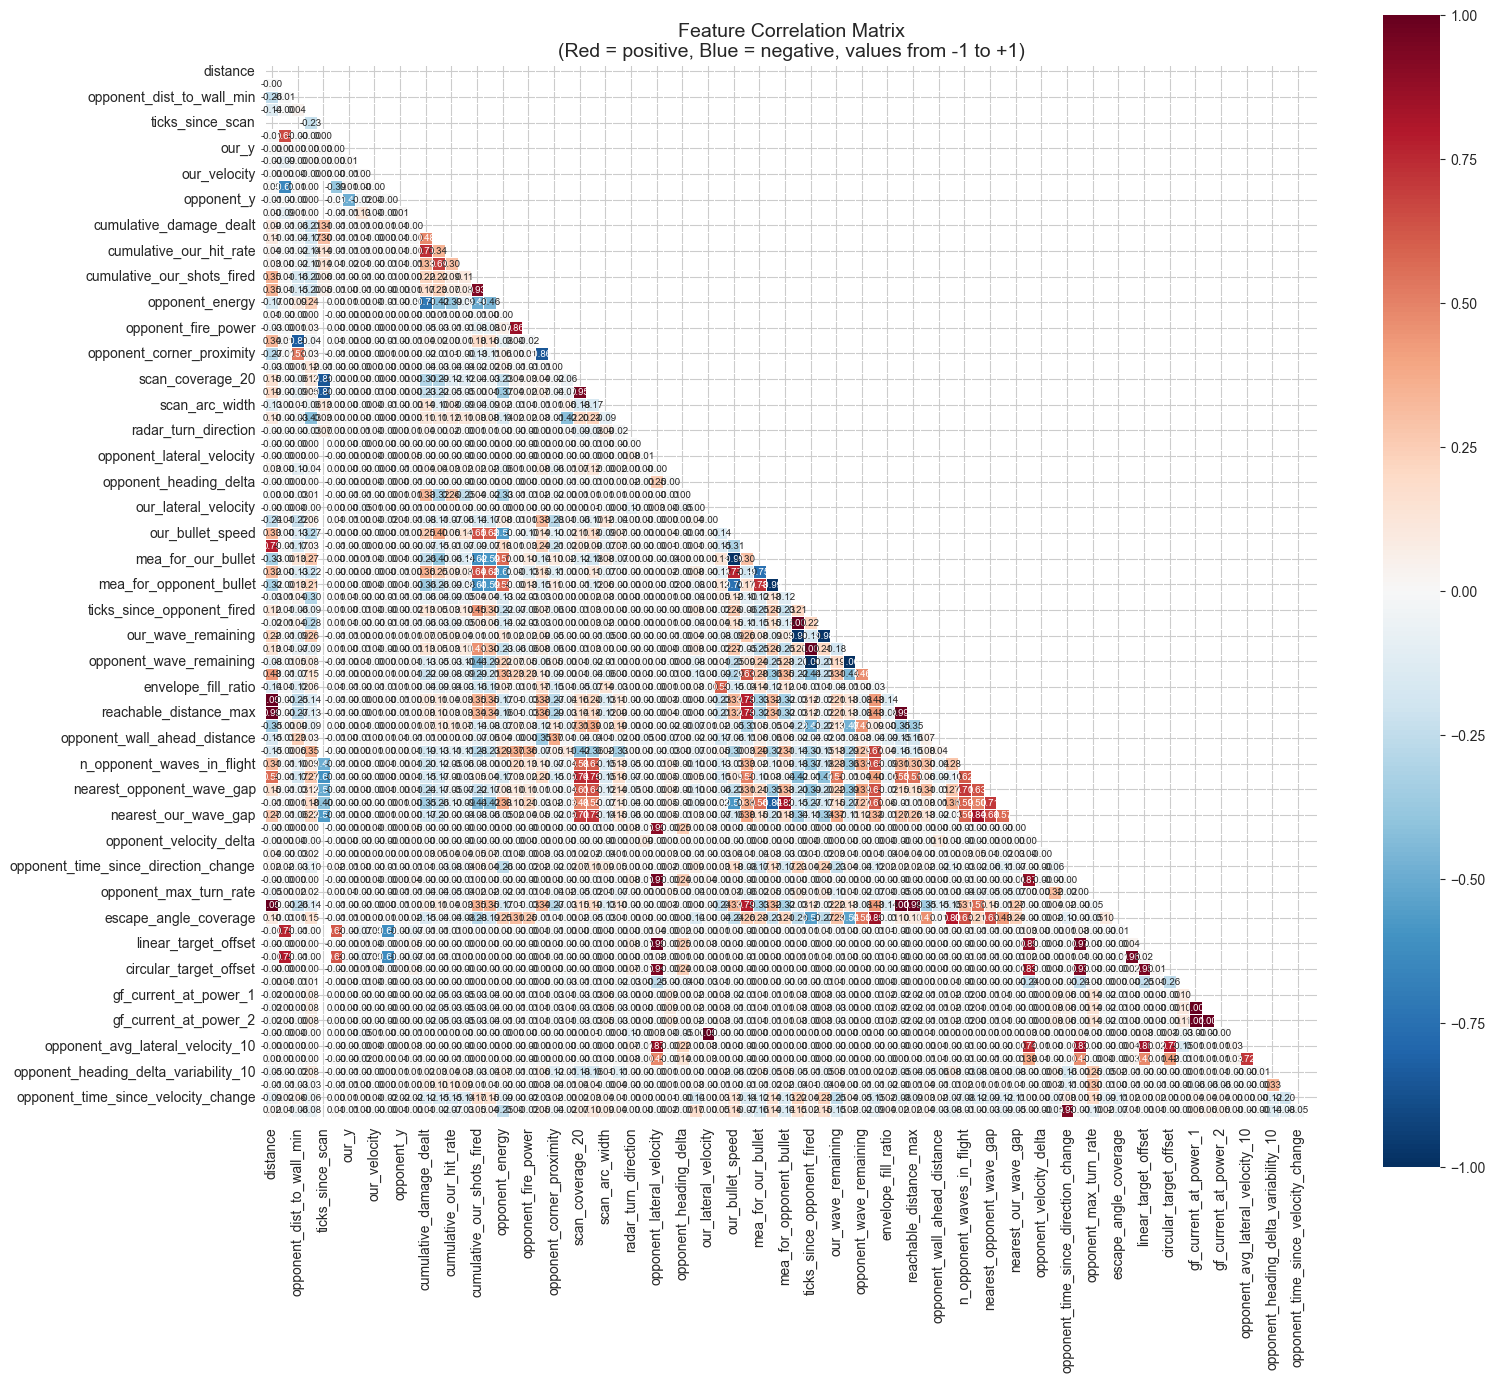

In [2]:
# --- Correlation matrix ---
corr = ticks[feature_cols].corr()

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))  # Hide upper triangle (it's a mirror)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 7})
ax.set_title("Feature Correlation Matrix\n(Red = positive, Blue = negative, values from -1 to +1)", fontsize=14)
plt.tight_layout()
plt.show()

## Top Correlated Pairs — Scatter Plots

Let's find the pairs of features with the strongest correlations and plot them. Each dot is one tick. If dots form a line → strong correlation.

Top 6 most correlated feature pairs:
  opponent_guess_factor ↔ our_lateral_velocity: r = 1.000
  distance ↔ distance_norm: r = 1.000
  gf_current_at_power_1_5 ↔ gf_current_at_power_2: r = 0.999
  gf_current_at_power_1 ↔ gf_current_at_power_1_5: r = 0.999
  opponent_wave_distance ↔ opponent_wave_remaining: r = -0.999
  gf_current_at_power_1 ↔ gf_current_at_power_2: r = 0.998


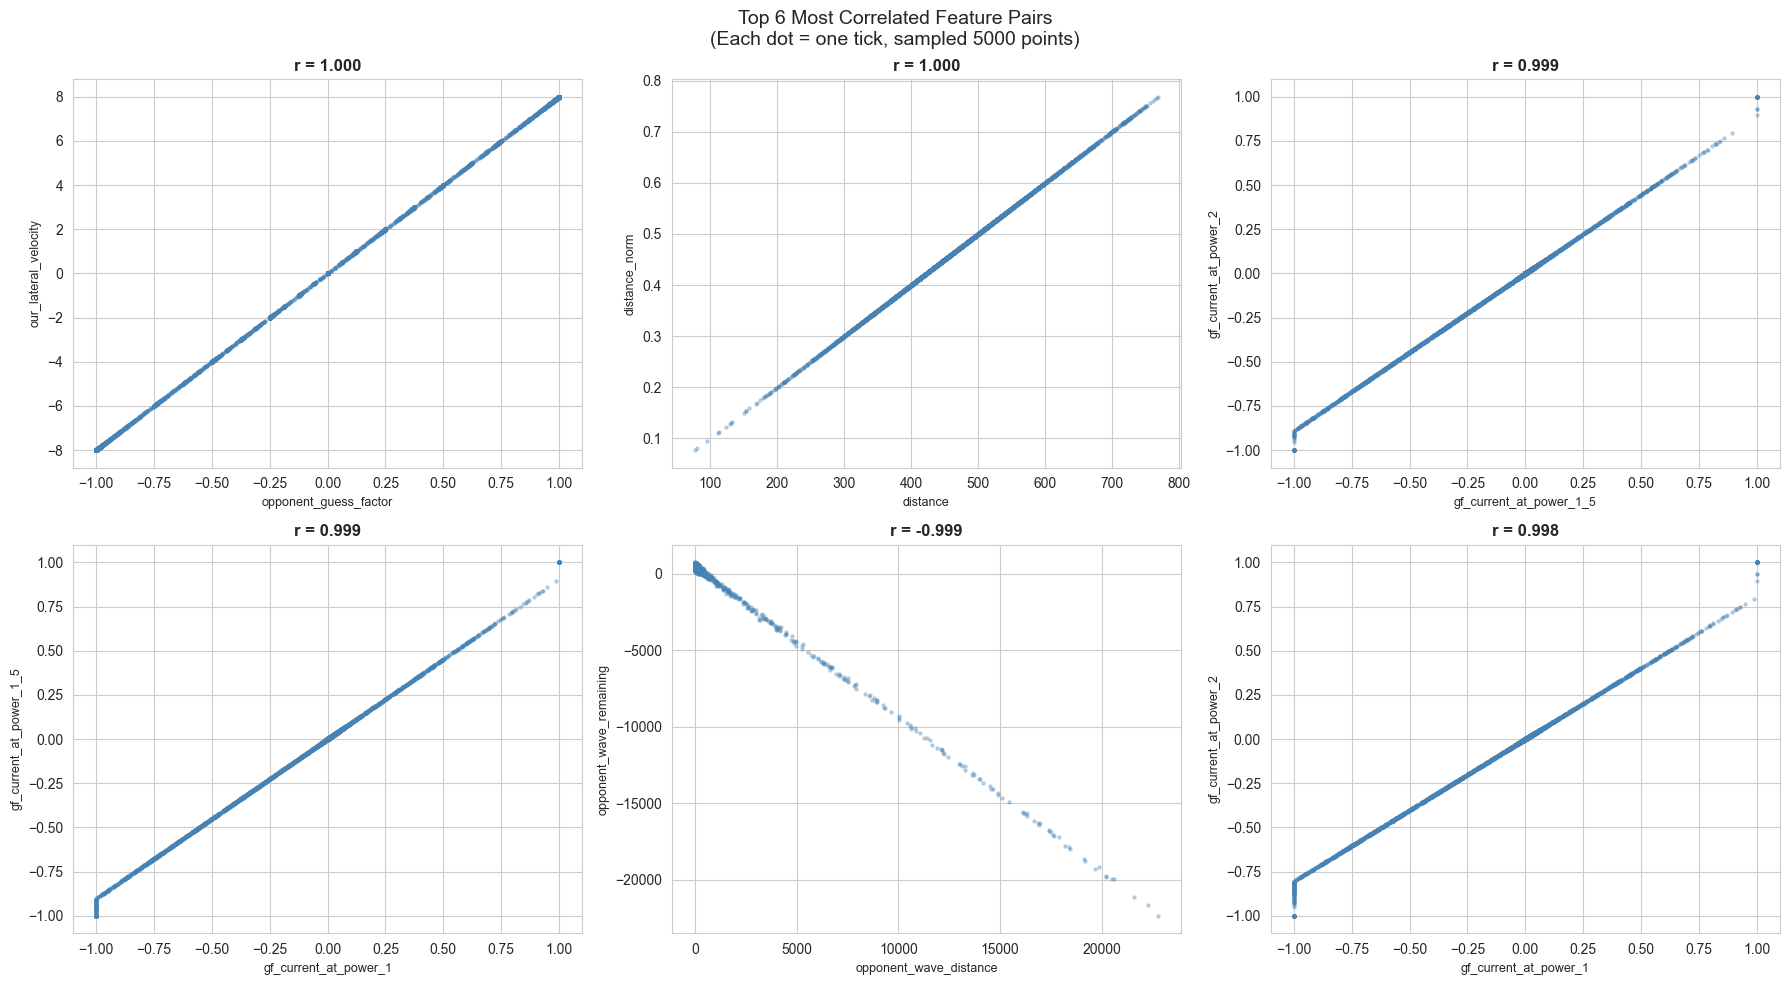

In [3]:
# --- Find top 6 correlated pairs (excluding self-correlation and perfect 1.0) ---
corr_pairs = corr.unstack().reset_index()
corr_pairs.columns = ['feature_1', 'feature_2', 'correlation']
corr_pairs = corr_pairs[corr_pairs['feature_1'] < corr_pairs['feature_2']]  # Remove duplicates
corr_pairs['abs_corr'] = corr_pairs['correlation'].abs()
top_pairs = corr_pairs.nlargest(6, 'abs_corr')

print("Top 6 most correlated feature pairs:")
for _, row in top_pairs.iterrows():
    print(f"  {row['feature_1']} ↔ {row['feature_2']}: r = {row['correlation']:.3f}")

# Scatter plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Sample for performance (266K dots would be slow)
sample = ticks.sample(min(5000, len(ticks)), random_state=42)

for i, (_, row) in enumerate(top_pairs.iterrows()):
    ax = axes[i]
    f1, f2, r = row['feature_1'], row['feature_2'], row['correlation']
    ax.scatter(sample[f1], sample[f2], alpha=0.3, s=5, c='steelblue')
    ax.set_xlabel(f1, fontsize=9)
    ax.set_ylabel(f2, fontsize=9)
    ax.set_title(f"r = {r:.3f}", fontweight='bold')

fig.suptitle("Top 6 Most Correlated Feature Pairs\n(Each dot = one tick, sampled 5000 points)", fontsize=14)
plt.tight_layout()
plt.show()

## Which Features Predict Opponent Firing?

The `opponent_fired` column is 0 or 1 (did the opponent fire this tick?). We can compute the **point-biserial correlation** — same formula as Pearson, but one variable is binary (0/1).

A high positive correlation means: when this feature is large, the opponent is more likely to fire.
A high negative correlation means: when this feature is large, the opponent is less likely to fire.

D:\robocode-autopilot\intuition\.venv\lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
D:\robocode-autopilot\intuition\.venv\lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


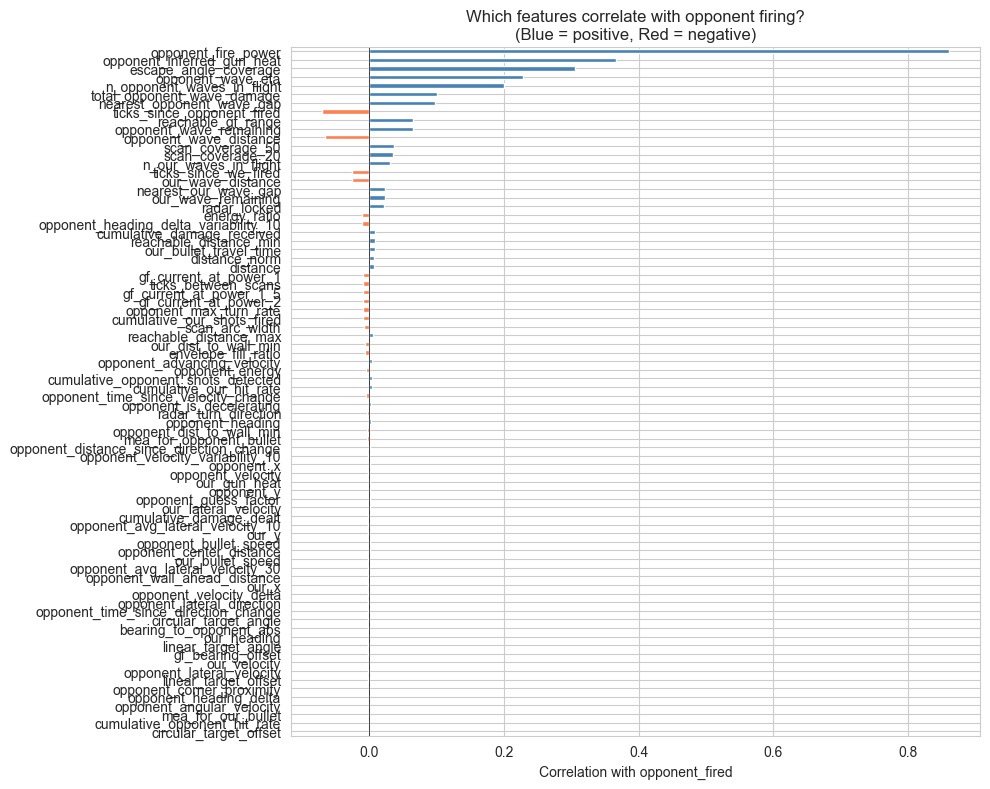


Top predictors of opponent firing:
  opponent_fire_power: r = 0.860 ↑
  opponent_inferred_gun_heat: r = 0.367 ↑
  escape_angle_coverage: r = 0.305 ↑
  opponent_wave_eta: r = 0.229 ↑
  n_opponent_waves_in_flight: r = 0.201 ↑


In [4]:
# --- Correlation of each feature with opponent_fired ---
if 'opponent_fired' in ticks.columns:
    # Only use ticks where scan was available (opponent_fired is NaN otherwise)
    scan_ticks = ticks[ticks['scan_available'] == 1].copy()
    
    fire_corr = scan_ticks[feature_cols].corrwith(scan_ticks['opponent_fired']).dropna()
    fire_corr = fire_corr.drop('opponent_fired', errors='ignore')
    fire_corr = fire_corr.reindex(fire_corr.abs().sort_values(ascending=True).index)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    colors = ['steelblue' if v >= 0 else 'coral' for v in fire_corr.values]
    fire_corr.plot.barh(ax=ax, color=colors)
    ax.set_xlabel("Correlation with opponent_fired")
    ax.set_title("Which features correlate with opponent firing?\n(Blue = positive, Red = negative)")
    ax.axvline(x=0, color='black', linewidth=0.5)
    plt.tight_layout()
    plt.show()
    
    print("\nTop predictors of opponent firing:")
    for feat, r in fire_corr.abs().nlargest(5).items():
        direction = "↑" if fire_corr[feat] > 0 else "↓"
        print(f"  {feat}: r = {fire_corr[feat]:.3f} {direction}")
else:
    print("opponent_fired column not found")

## Per-Robot Correlation Differences

Do different robots show different relationships between features? For example, maybe DrussGT fires more at close range (negative distance↔fired correlation) while others fire at all ranges.

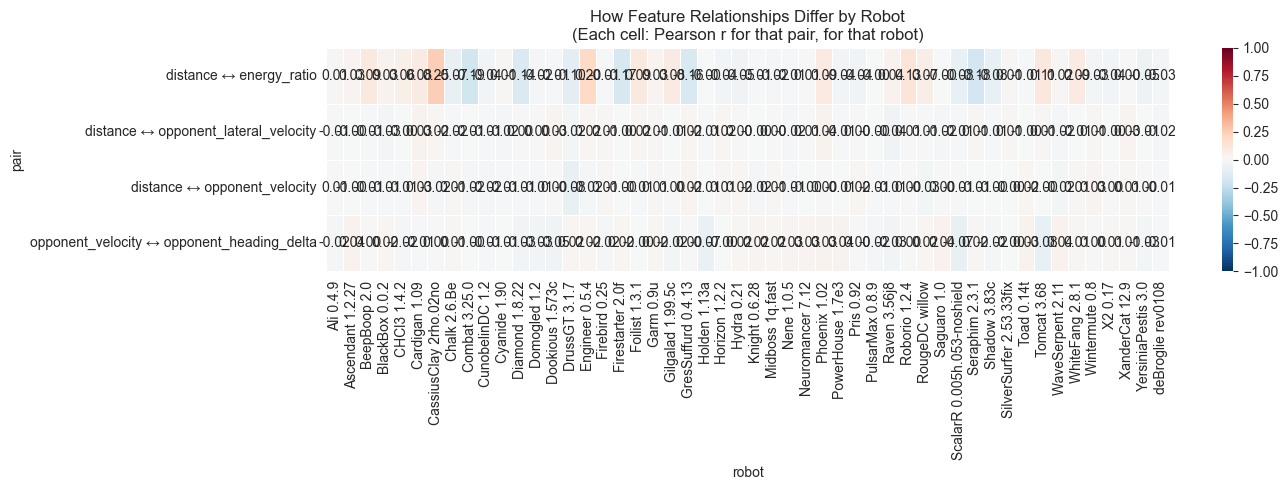

In [5]:
# --- Per-robot correlation of distance vs key features ---
focus_pairs = [
    ('distance', 'opponent_velocity'),
    ('distance', 'opponent_lateral_velocity'),
    ('distance', 'energy_ratio'),
    ('opponent_velocity', 'opponent_heading_delta'),
]
# Keep only pairs where both columns exist
focus_pairs = [(a, b) for a, b in focus_pairs if a in ticks.columns and b in ticks.columns]

robots = sorted(ticks['robot_name'].unique())

results = []
for robot in robots:
    rdata = ticks[ticks['robot_name'] == robot]
    for f1, f2 in focus_pairs:
        r = rdata[[f1, f2]].dropna().corr().iloc[0, 1]
        results.append({'robot': robot, 'pair': f"{f1} ↔ {f2}", 'correlation': r})

result_df = pd.DataFrame(results)
pivot = result_df.pivot(index='pair', columns='robot', values='correlation')

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax,
            linewidths=0.5, vmin=-1, vmax=1)
ax.set_title("How Feature Relationships Differ by Robot\n(Each cell: Pearson r for that pair, for that robot)")
plt.tight_layout()
plt.show()